In [31]:
#This code is when you dont have data and you want to test model
import numpy as np

# Generate random adjacency matrices with shape (2300, 306, 306)
adjacency_matrices = np.random.randint(0, 2300, (230, 306, 306))

# Generate random labels with shape (1, 2300)
labels = np.random.randint(0, 2, (1, 230))

# Print the shapes to confirm
print("Adjacency Matrices Shape:", adjacency_matrices.shape)
print("Labels Shape:", labels.shape)


Adjacency Matrices Shape: (230, 306, 306)
Labels Shape: (1, 230)


In [32]:
labels=np.transpose(labels,(1,0))
adjacency_matrices.shape

(230, 306, 306)

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.nn import GCNConv, GATConv, ChebConv, SAGEConv, global_mean_pool
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

In [34]:
class BrainConnectivityDataset(Dataset):
    def __init__(self, adjacency_matrices, labels, transform=None, pre_transform=None):
        self.adjacency_matrices = adjacency_matrices
        self.labels = labels
        super(BrainConnectivityDataset, self).__init__(None, transform, pre_transform)

    def len(self):
        return len(self.labels)

    def get(self, idx):
        edge_index = self.adjacency_matrix_to_edge_index(self.adjacency_matrices[idx])
        x = torch.ones((self.adjacency_matrices.shape[1], 1), dtype=torch.float)
        y = torch.tensor([self.labels[idx]], dtype=torch.long)
        data = Data(x=x, edge_index=edge_index, y=y)
        return data

    @staticmethod
    def adjacency_matrix_to_edge_index(matrix):
        edge_index = []
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                if matrix[i, j]:  # If there is an edge
                    edge_index.append([i, j])
        return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

# # Load the .mat files
# labels = loadmat('path_to_labels.mat')['variable_name'].squeeze()

# Split the dataset into training and testing sets (Thos os no)
train_indices, test_indices = train_test_split(range(len(labels)), test_size=0.2, random_state=42)
train_data = adjacency_matrices[train_indices]
test_data = adjacency_matrices[test_indices]
train_labels = labels[train_indices]
test_labels = labels[test_indices]

# Create the datasets
train_dataset = BrainConnectivityDataset(train_data, train_labels)
test_dataset = BrainConnectivityDataset(test_data, test_labels)

Epoch 1/10


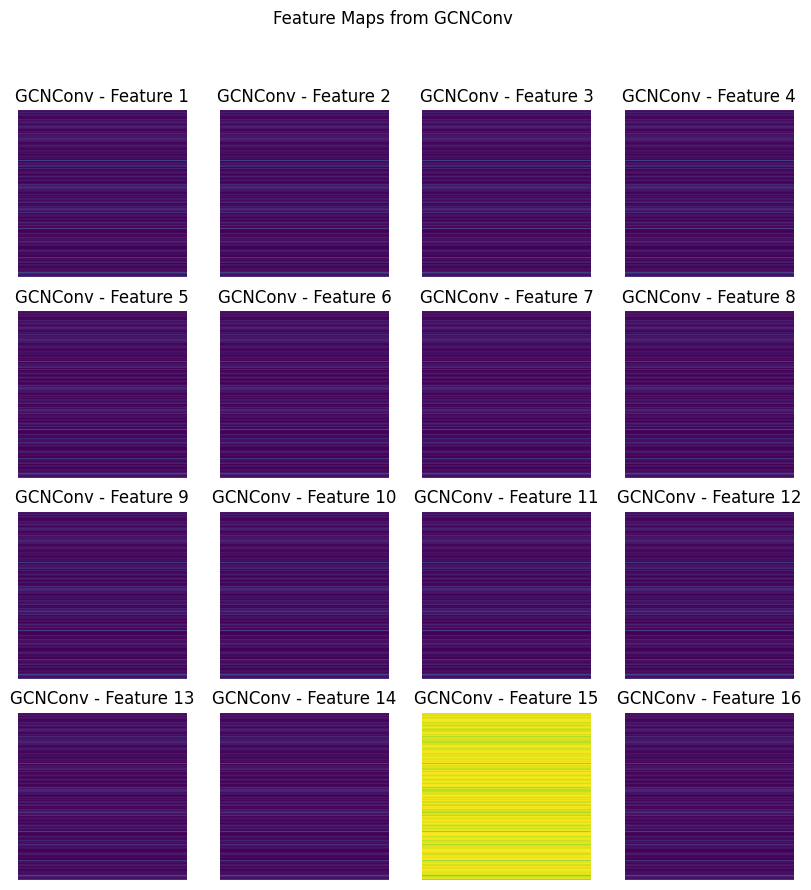

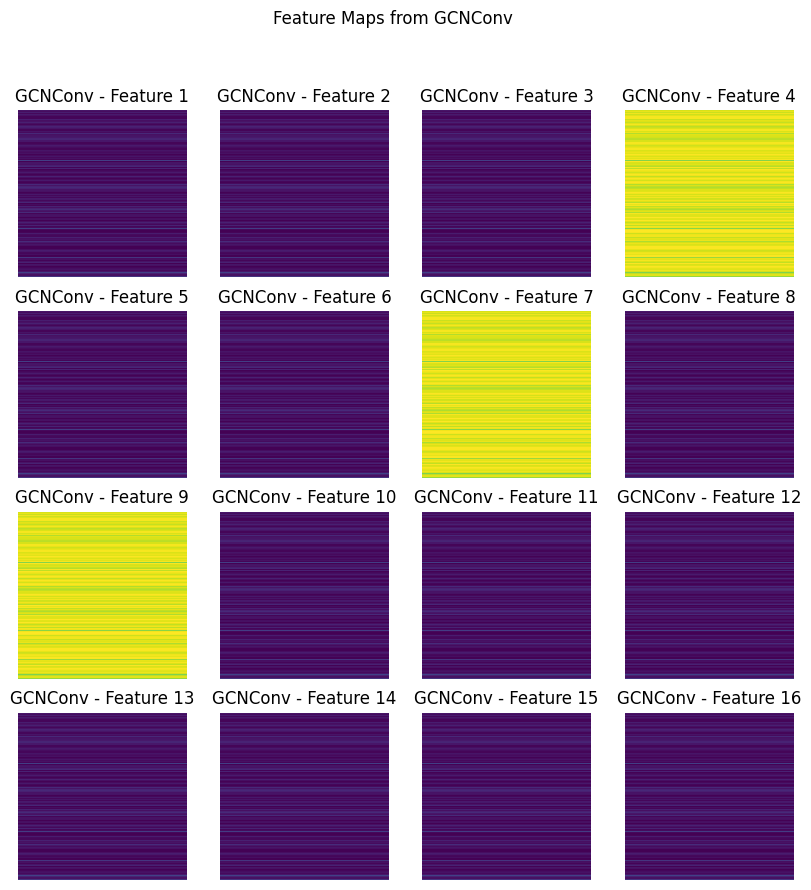

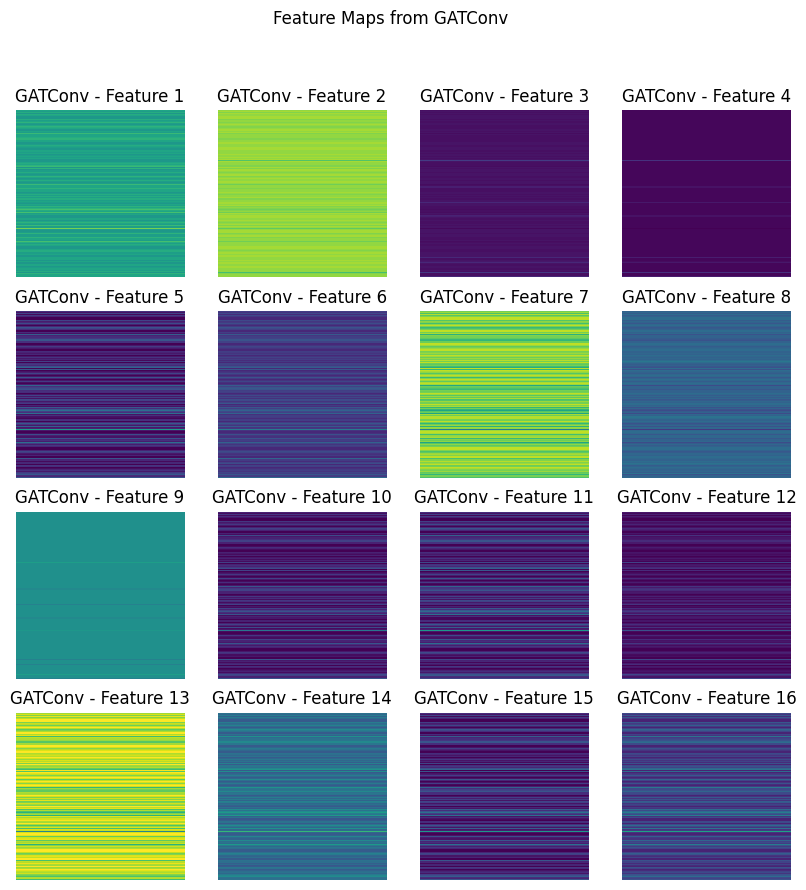

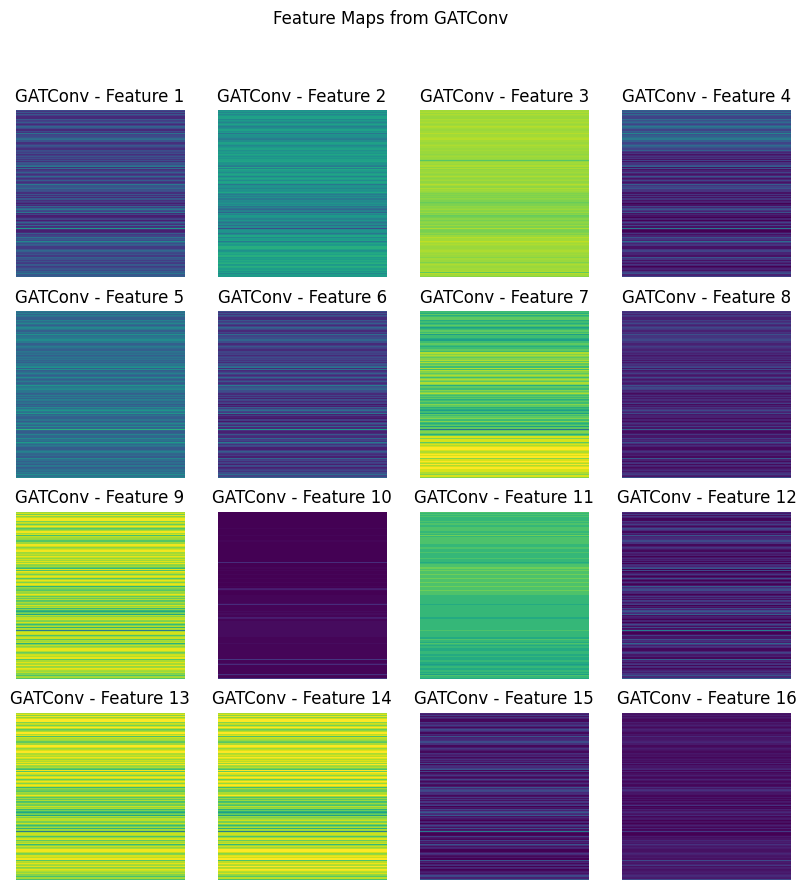

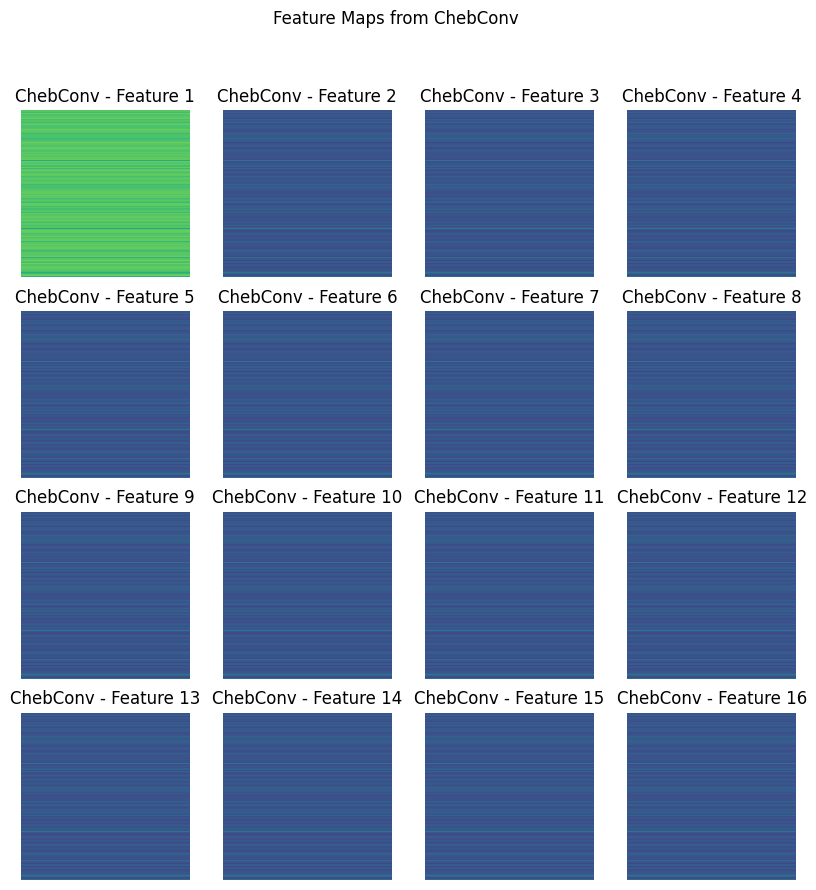

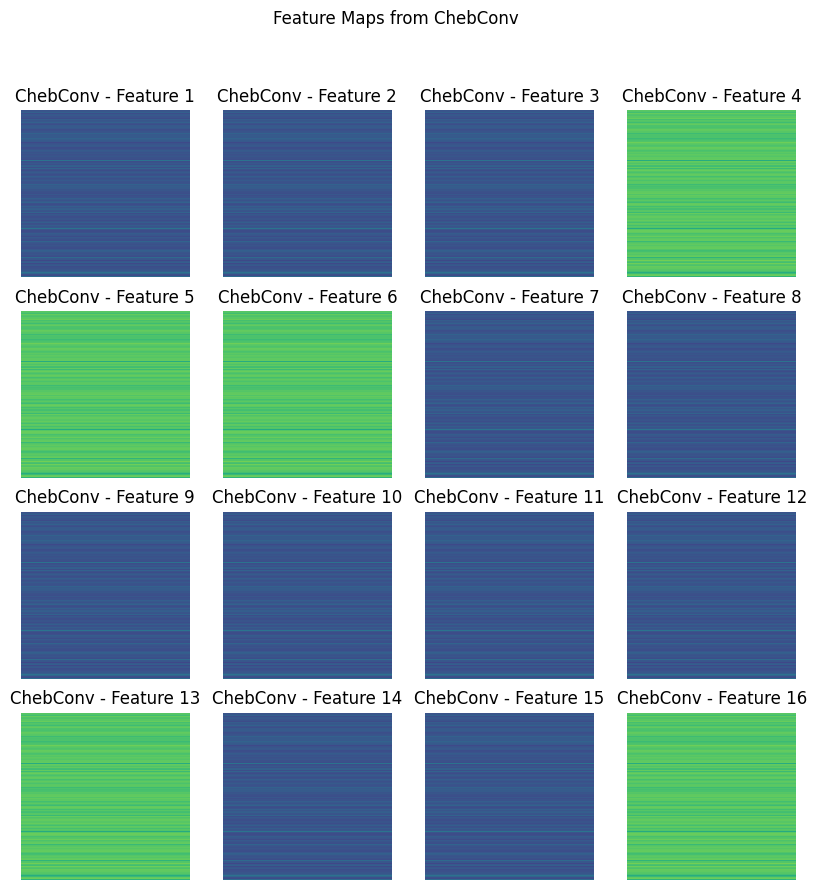

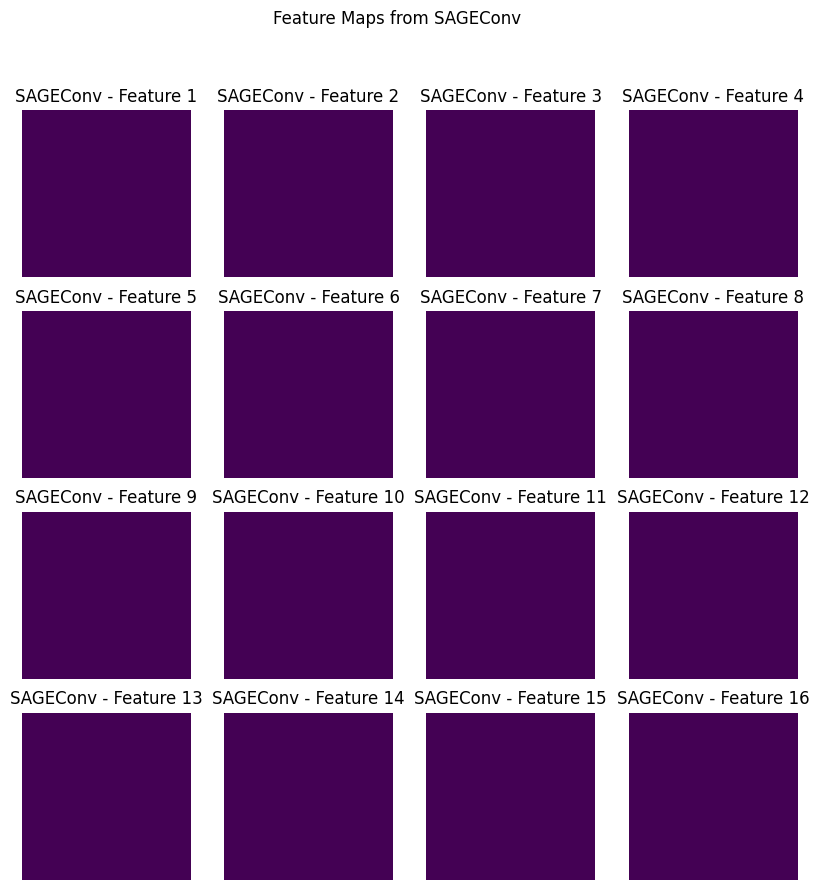

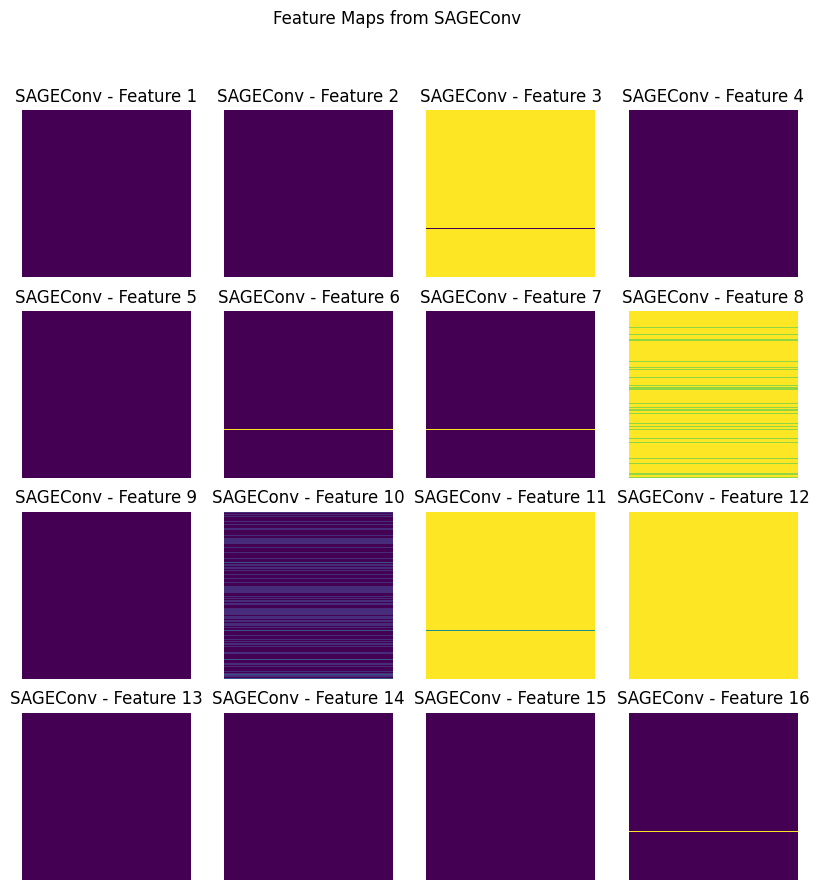

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, ChebConv, SAGEConv, global_mean_pool
import matplotlib.pyplot as plt

# Define the BrainConnectivityNet model
class BrainConnectivityNet(nn.Module):
    def __init__(self, num_nodes, num_classes):
        super(BrainConnectivityNet, self).__init__()
        # GCN branch
        self.gcn1 = GCNConv(num_nodes, 126)
        self.gcn2 = GCNConv(126, 96)

        # GAT branch
        self.gat1 = GATConv(num_nodes, 126)
        self.gat2 = GATConv(126, 96)

        # Chebyshev branch
        self.cheb1 = ChebConv(num_nodes, 126, K=2)
        self.cheb2 = ChebConv(126, 96, K=2)

        # GraphSAGE branch
        self.sage1 = SAGEConv(num_nodes, 126)
        self.sage2 = SAGEConv(126, 96)

        # Pooling layer
        self.pool = global_mean_pool

        # Classifier
        self.classifier = nn.Linear(96 * 4, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Node features are all ones
        x = torch.ones((data.num_nodes, 306), dtype=torch.float)

        # GCN branch
        x_gcn1 = F.relu(self.gcn1(x, edge_index))
        x_gcn2 = F.relu(self.gcn2(x_gcn1, edge_index))

        # GAT branch
        x_gat1 = F.relu(self.gat1(x, edge_index))
        x_gat2 = F.relu(self.gat2(x_gat1, edge_index))

        # Chebyshev branch
        x_cheb1 = F.relu(self.cheb1(x, edge_index))
        x_cheb2 = F.relu(self.cheb2(x_cheb1, edge_index))

        # GraphSAGE branch
        x_sage1 = F.relu(self.sage1(x, edge_index))
        x_sage2 = F.relu(self.sage2(x_sage1, edge_index))

        # Concatenate the outputs from all branches
        x = torch.cat((x_gcn2, x_gat2, x_cheb2, x_sage2), dim=1)

        # Apply the pooling layer to get graph-level representation
        x = self.pool(x, batch)

        # Apply the classification layer
        x = self.classifier(x)
    
        # Return the final output and all intermediate feature maps
        return F.log_softmax(x, dim=1)


# Function to visualize feature maps
def visualize_feature_maps(feature_maps, layer_name):
    # Check if feature_maps is a 2D tensor
    if len(feature_maps.shape) == 2:
        num_features = feature_maps.shape[1]
        num_plots = min(num_features, 16)  # Visualize up to 16 feature maps
        fig, axs = plt.subplots(4, 4, figsize=(10, 10))

        for i in range(num_plots):
            ax = axs[i // 4, i % 4]
            # Reshape the feature map to be 2D for visualization if needed
            feature_map = feature_maps[:, i].view(-1, 1).detach().numpy()
            ax.imshow(feature_map, cmap='viridis', aspect='auto')
            ax.axis('off')
            ax.set_title(f'{layer_name} - Feature {i+1}')

        plt.suptitle(f'Feature Maps from {layer_name}')
        plt.show()
    else:
        print(f"Skipping visualization for {layer_name}, as the feature map shape is not 2D.")


# Hook function to store feature maps
def hook_fn(module, input, output):
    feature_maps[module] = output

# Create DataLoaders for training and testing
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
# Initialize the model
model = BrainConnectivityNet(num_nodes=306, num_classes=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Dictionary to store feature maps
feature_maps = {}
num_epochs = 10
# Register hooks for specific layers
model.gcn1.register_forward_hook(hook_fn)
model.gcn2.register_forward_hook(hook_fn)
model.gat1.register_forward_hook(hook_fn)
model.gat2.register_forward_hook(hook_fn)
model.cheb1.register_forward_hook(hook_fn)
model.cheb2.register_forward_hook(hook_fn)
model.sage1.register_forward_hook(hook_fn)
model.sage2.register_forward_hook(hook_fn)
# Register hooks for other layers (e.g., GAT, Cheb, SAGE)
i =1
model.train()
for epoch in range(1):
    total_loss = 0
    feature_maps.clear()  # Clear feature maps at the start of each epoch
    for data in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, data.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # After each epoch, visualize the feature maps
    print(f'Epoch {epoch + 1}/{num_epochs}')
    for layer, feature_map in feature_maps.items():
        visualize_feature_maps(feature_map, layer.__class__.__name__)


In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, ChebConv, SAGEConv, global_mean_pool
from torch_geometric.data import DataLoader
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig, MaskType
import matplotlib.pyplot as plt

# Define the BrainConnectivityNet model
class BrainConnectivityNet(nn.Module):
    def __init__(self, num_nodes, num_classes):
        super(BrainConnectivityNet, self).__init__()
        # Define layers as before
        self.gcn1 = GCNConv(num_nodes, 126)
        self.gcn2 = GCNConv(126, 96)

        self.gat1 = GATConv(num_nodes, 126)
        self.gat2 = GATConv(126, 96)

        self.cheb1 = ChebConv(num_nodes, 126, K=2)
        self.cheb2 = ChebConv(126, 96, K=2)

        self.sage1 = SAGEConv(num_nodes, 126)
        self.sage2 = SAGEConv(126, 96)

        self.pool = global_mean_pool
        self.classifier = nn.Linear(96 * 4, num_classes)

    def forward(self, x, edge_index, batch=None):
        # Node features are all ones
        x = torch.ones((x.size(0), 306), dtype=torch.float)

        # GCN branch
        x_gcn1 = F.relu(self.gcn1(x, edge_index))
        x_gcn2 = F.relu(self.gcn2(x_gcn1, edge_index))

        # GAT branch
        x_gat1 = F.relu(self.gat1(x, edge_index))
        x_gat2 = F.relu(self.gat2(x_gat1, edge_index))

        # Chebyshev branch
        x_cheb1 = F.relu(self.cheb1(x, edge_index))
        x_cheb2 = F.relu(self.cheb2(x_cheb1, edge_index))

        # GraphSAGE branch
        x_sage1 = F.relu(self.sage1(x, edge_index))
        x_sage2 = F.relu(self.sage2(x_sage1, edge_index))

        # Concatenate the outputs from all branches
        x = torch.cat((x_gcn2, x_gat2, x_cheb2, x_sage2), dim=1)

        # Apply the pooling layer to get graph-level representation
        x = self.pool(x, batch)

        # Apply the classification layer
        x = self.classifier(x)

        return F.log_softmax(x, dim=1)


# Function to visualize explanation
def visualize_explanation(explanation, data):
    edge_mask = explanation.edge_mask
    node_mask = explanation.node_mask

    # Plot edge mask
    if edge_mask is not None:
        plt.figure(figsize=(8, 4))
        plt.title("Edge Mask")
        plt.hist(edge_mask.cpu().numpy(), bins=50)
        plt.xlabel("Edge Importance")
        plt.ylabel("Frequency")
        plt.show()

    # Plot node mask
    if node_mask is not None:
        plt.figure(figsize=(8, 4))
        plt.title("Node Mask")
        plt.hist(node_mask.cpu().numpy(), bins=50)
        plt.xlabel("Node Importance")
        plt.ylabel("Frequency")
        plt.show()


# Create DataLoaders for training
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Initialize the model
model = BrainConnectivityNet(num_nodes=306, num_classes=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Initialize the Explainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type=MaskType.attributes,
    edge_mask_type=MaskType.object,
    model_config=ModelConfig(
        mode='multiclass_classification',
        task_level='node',
        return_type='log_probs'
    ),
)

# Loop through the data loader to generate explanations
for data in train_loader:
    model.eval()
    with torch.no_grad():
        # Generate explanation for the data
        explanation = explainer(x=data.x, edge_index=data.edge_index, batch=data.batch if hasattr(data, 'batch') else None)
        
        # Visualize the explanation
        visualize_explanation(explanation, data)

    # For demonstration purposes, we break after the first batch
    break


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [58]:
for data in train_loader:
 data=data[0]

print(data)
from torch.nn import Linear
import torch.nn.functional as F 
from torch_geometric.nn import GATConv
embedding_size = 128

class GNN(torch.nn.Module):
    def __init__(self):
        # Init parent
        super(GNN, self).__init__()

        # GCN layers
        self.initial_conv = GATConv(data.num_features, embedding_size)
        self.conv1 = GATConv(embedding_size, embedding_size)

        # Output layer
        self.out = Linear(embedding_size, 1)

    def forward(self, x, edge_index):
        emb = F.relu(self.initial_conv(x, edge_index))
        emb = F.relu(self.conv1(emb, edge_index))
        return self.out(emb)

model = GNN()
print(model)
print("Number of parameters: ", sum(p.numel() for p in model.parameters()))

Data(x=[306, 1], edge_index=[2, 93593], y=[1, 1])
GNN(
  (initial_conv): GATConv(1, 128, heads=1)
  (conv1): GATConv(128, 128, heads=1)
  (out): Linear(in_features=128, out_features=1, bias=True)
)
Number of parameters:  17409


In [59]:
# Add train and test masks
num_nodes = data.x.shape[0]
ones = torch.ones(num_nodes)
ones[4000:] = 0
data.train_mask = ones.bool()
data.test_mask = ~data.train_mask.bool()

print("Train nodes: ", sum(data.train_mask))
print("Test nodes: ", sum(data.test_mask))

Train nodes:  tensor(306)
Test nodes:  tensor(0)


In [60]:
data.train_mask

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

In [61]:
data.test_mask

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 